In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
file_path = "Linux_2k.log_structured.csv"
df = pd.read_csv(file_path, header=None, names=["log"])

In [3]:
# Convert logs to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=500)
X_tfidf = vectorizer.fit_transform(df["log"]).toarray()

In [4]:
# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [5]:
# Reshape data for LSTM (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [9]:
# Define LSTM Autoencoder
timesteps = X_reshaped.shape[1]
features = X_reshaped.shape[2]

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='relu', return_sequences=True)(input_layer) #using rectified linear unit
encoded = LSTM(32, activation='relu', return_sequences=False)(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')    #adaptive moment estimation for optimization

In [10]:
# Train the model
history = autoencoder.fit(X_reshaped, X_reshaped, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0135 - val_loss: 0.0128
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0109 - val_loss: 0.0121
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0075 - val_loss: 0.0104
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0058 - val_loss: 0.0104
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 - val_loss: 0.0098
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - val_loss: 0.0087
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022 - val_loss: 0.0085
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - val_loss: 0.0085
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0086
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0087
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 0.0088
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - val_l

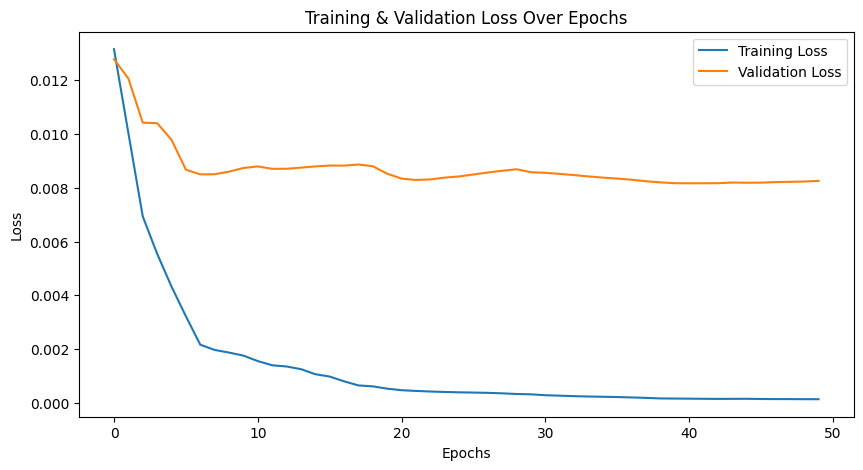

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Mean Absolute Error (MAE): 0.0026495972086221535
Mean Squared Error (MSE): 0.0009532647695868817
Root Mean Squared Error (RMSE): 0.030874986147152873


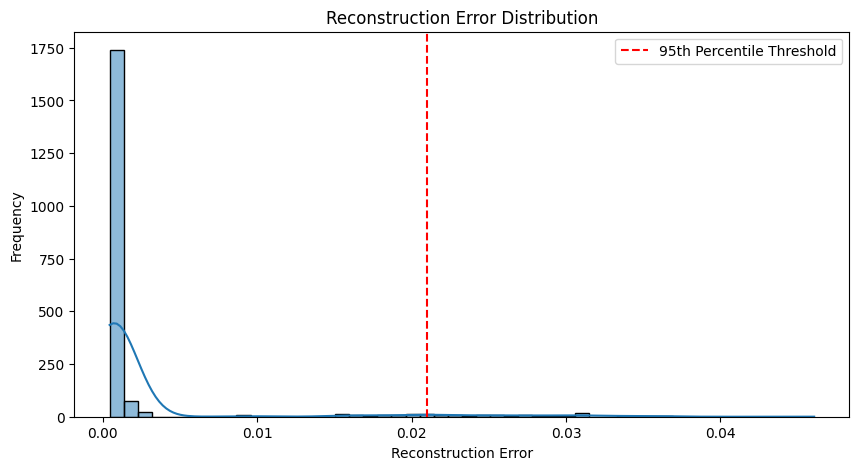

Anomaly Threshold: 0.021011599425931202

Detected Anomalies:
                                                                                                                                                   log  \
136  Jun 18 02:23:10 combo ftpd       31277 User unknown timed out after 900 seconds at Sat... E112  User unknown timed out after <*> seconds at <*...   
167  Jun 20 04:44:39 combo snmpd      2318  Received SNMP packet(s) from 67.170.148.126        E88                    Received SNMP packet(s) from <*>   
897  Jul 7  08:06:12 combo gpm        2094  imps2: Auto-detected intellimouse PS/2             E51            imps2: Auto-detected intellimouse PS/<*>   
899  Jul 7  08:06:15 combo -- root    2421  ROOT LOGIN ON tty2                                 E91                                  ROOT LOGIN ON tty2   
1243 Jul 11 11:33:17 combo gdm-binary 2803  Couldn't authenticate user                         E31                          Couldn't authenticate user   
...            

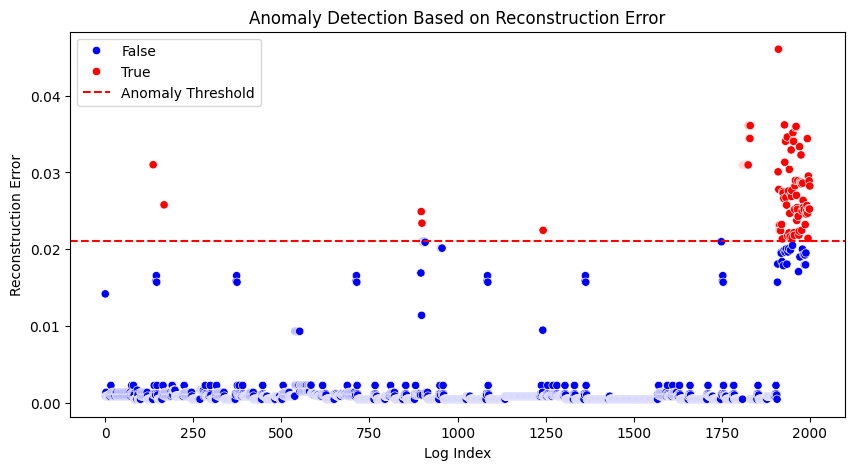

Anomalies saved to detected_anomalies.csv
Full log analysis saved to log_anomaly_results.csv


In [11]:
# Import additional metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.legend()
plt.show()

# Get reconstruction error
X_pred = autoencoder.predict(X_reshaped)
reconstruction_error = np.mean(np.abs(X_pred - X_reshaped), axis=(1, 2))

# Compute additional evaluation metrics
mae = mean_absolute_error(X_reshaped.flatten(), X_pred.flatten())
mse = mean_squared_error(X_reshaped.flatten(), X_pred.flatten())
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot reconstruction error
plt.figure(figsize=(10, 5))
sns.histplot(reconstruction_error, bins=50, kde=True)
plt.axvline(np.percentile(reconstruction_error, 95), color='r', linestyle='dashed', label="95th Percentile Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

# Set anomaly threshold
threshold = np.percentile(reconstruction_error, 95)
print(f"Anomaly Threshold: {threshold}")

# Detect anomalies
df["Reconstruction Error"] = reconstruction_error
df["Anomaly"] = df["Reconstruction Error"] > threshold

# Print detected anomalies
anomalies = df[df["Anomaly"] == True]
print("\nDetected Anomalies:")
print(anomalies)

# Plot anomalies
plt.figure(figsize=(10, 5))
sns.scatterplot(x=range(len(reconstruction_error)), y=reconstruction_error, hue=df["Anomaly"], palette={True: "red", False: "blue"})
plt.axhline(threshold, color='r', linestyle='dashed', label="Anomaly Threshold")
plt.xlabel("Log Index")
plt.ylabel("Reconstruction Error")
plt.title("Anomaly Detection Based on Reconstruction Error")
plt.legend()
plt.show()

# Save anomalies to CSV
anomalies.to_csv("lstm_detected_anomalies.csv", index=False)

# Save the entire dataset with reconstruction errors and anomaly flags
df.to_csv("log_anomaly_results.csv", index=False)

print("Anomalies saved to detected_anomalies.csv")
print("Full log analysis saved to log_anomaly_results.csv")

